# **ML model:**

This notebook consists of the following steps:

1. Master setup cell

2. ML imports cell

3. Train test split cell

4. Train model cell

5. Evaluation cell

6. Figure 5 feature importance and ROC cell

7. Figure 6 confusion matrix cell

8. Classification report save cell

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("All liberaries are loaded successfully")


All liberaries are loaded successfully


In [19]:
df = pd.read_excel("/content/ML targets (7).xlsx")
print('Shape of the dataset:', df.shape)
print('\nLabel counts:')
print(df['RMSD_Mimic_Target (Y)'].value_counts())
print('\nColumn Name:')
print(df.columns.tolist())
print('\nMissing values:')
print(df.isnull().sum()[df.isnull().sum()>0])


Shape of the dataset: (399, 23)

Label counts:
RMSD_Mimic_Target (Y)
Y    262
N    137
Name: count, dtype: int64

Column Name:
['Organism', 'Protein', 'Position', 'HLA Haplotype', 'Pathogen Peptide', 'pathogen length', '%Rank_EL(X)', 'Aff(nM)(X)', 'Immunogenicity', 'Type of MHC', 'Human_match', 'BLOSUM80 score', 'Identity percentage', 'Alignment length (Sequence)', 'Identical aa', 'Positions', 'Human Peptide', 'Human length', 'Alignment Length (Structure)', 'Structural RMSD', 'TM-align score (Human chain 2)', 'Structural alignment coverage %', 'RMSD_Mimic_Target (Y)']

Missing values:
Series([], dtype: int64)


In [20]:
df['BLOSUM80 score'] = pd.to_numeric(df['BLOSUM80 score'], errors='coerce')
df['pathogen length'] = pd.to_numeric(df['pathogen length'], errors='coerce')
df['Alignment length (Sequence)'] = pd.to_numeric(df['Alignment length (Sequence)'], errors='coerce')
df['BLOSUM80_per_residue'] = df['BLOSUM80 score'] / df['Alignment length (Sequence)']

df['Alignment_coverage_sequence'] = (df['Alignment length (Sequence)'] / df['pathogen length'] * 100).clip(upper=100)

print("New shape:", df.shape)  # Should now say (399, 25)
print("\nNew columns confirmed:")
print(df[['BLOSUM80_per_residue', 'Alignment_coverage_sequence']].head())


New shape: (399, 25)

New columns confirmed:
   BLOSUM80_per_residue  Alignment_coverage_sequence
0                   NaN                          NaN
1              4.111111                         90.0
2              2.916667                        100.0
3              4.000000                         90.0
4              4.375000                         80.0


In [21]:
columns_to_convert = [
    'BLOSUM80 score',
    'Identity percentage',
    'Alignment length (Sequence)',
    'Identical aa',
    'pathogen length',
    'Human length',
    '%Rank_EL(X)',
    'Aff(nM)(X)',
    'Structural RMSD',
    'TM-align score (Human chain 2)',
    'Structural alignment coverage %',
    'Alignment Length (Structure)'
]

for col in columns_to_convert:
  df[col] = pd.to_numeric(df[col], errors='coerce')

df['BLOSUM80_per_residue'] = df['BLOSUM80 score'] / df['Alignment length (Sequence)']
df['Alignment_coverage_sequence'] = (df['Alignment length (Sequence)'] / df['pathogen length'] * 100).clip(upper=100)
print('All Columns Converted Successfully!')
print('\nMissing values per column:')
print(df.isnull().sum()[df.isnull().sum()>0])

Y_group = df[df['RMSD_Mimic_Target (Y)'] == 'Y']
N_group = df[df['RMSD_Mimic_Target (Y)'] == 'N']

print(f'Y Group_size : {len(Y_group)}')
print(f'N Group_size : {len(N_group)}')



All Columns Converted Successfully!

Missing values per column:
BLOSUM80 score                    127
Identity percentage               127
Alignment length (Sequence)       128
Identical aa                      127
TM-align score (Human chain 2)      1
BLOSUM80_per_residue              128
Alignment_coverage_sequence       128
dtype: int64
Y Group_size : 262
N Group_size : 137


**Random Forest Classifier**

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import(
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

from sklearn.preprocessing import LabelEncoder

print('ML libraries imported succesfully!')

feature_cols_ml = [
    'BLOSUM80 score',
    'Identity percentage',
    'Alignment length (Sequence)',
    'Identical aa',
    'pathogen length',
    'Human length',
    '%Rank_EL(X)',
    'Aff(nM)(X)',
    'Structural alignment coverage %',
    'BLOSUM80_per_residue',
    'Alignment_coverage_sequence'
]

X = df[feature_cols_ml]
y = df['RMSD_Mimic_Target (Y)']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f'Label encoding: {le.classes_} -> {le.transform(le.classes_)}')

X_filled = X.fillna(X.median())
print(f'\nMissing values after filling: {X_filled.isnull().sum().sum()}')

X_train, X_test, y_train, y_test = train_test_split(
    X_filled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f'\nTraining set size: {len(X_train)} rows')
print(f'Test set size: {len(X_test)} rows')
print(f'Training Y count: {y_train.sum()}, N count: {len(y_train) - y_train.sum()}')
print(f'Test Y count: {y_test.sum()}, N count: {len(y_test) - y_test.sum()}')

ML libraries imported succesfully!
Label encoding: ['N' 'Y'] -> [0 1]

Missing values after filling: 0

Training set size: 319 rows
Test set size: 80 rows
Training Y count: 209, N count: 110
Test Y count: 53, N count: 27


* Label encoding: N=0, Y=1 — confirmed. The model will predict 1 for mimic and 0 for non-mimic.

* Missing values after filling: 0 — confirmed. The median filling worked perfectly.

* Training set: 319 rows, Test set: 80 rows — that is an 80/20 split as intended.

* Class ratio check:
Training: 209 Y vs 110 N = 1.9:1 ratio
Test: 53 Y vs 27 N = 1.96:1 ratio

**Both sets have almost identical ratios — this confirms the stratify worked correctly. The model trains and evaluates on proportionally balanced data.**

In [23]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)
print('Model trained successfully!!')

y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print('\n---Classification Report ---')
print(classification_report(y_test, y_pred, target_names=['Non- Mimic (N)', 'Confirmed Mimic (Y)']))

print('--- Confusion Matrix ---')
cm = confusion_matrix(y_test, y_pred)
print(cm)


auc = roc_auc_score(y_test, y_pred_proba)
print(f'\nAUC-ROC Score: {auc:.3f}')


Model trained successfully!!

---Classification Report ---
                     precision    recall  f1-score   support

     Non- Mimic (N)       1.00      0.85      0.92        27
Confirmed Mimic (Y)       0.93      1.00      0.96        53

           accuracy                           0.95        80
          macro avg       0.96      0.93      0.94        80
       weighted avg       0.95      0.95      0.95        80

--- Confusion Matrix ---
[[23  4]
 [ 0 53]]

AUC-ROC Score: 0.954


**AUC-ROC: 0.954**

* 0.5 is random guessing

* 0.7-0.8 is acceptable

* 0.8-0.9 is good

* above 0.9 is excellent.

We are at 0.954. The combined feature set — sequence metrics plus immunological features — is a very strong classifier for structural mimicry.

**Reading the grid:**

* 23 non-mimics correctly identified as N — true negatives.
* 4 non-mimics incorrectly called Y — false positives
* 0 mimics incorrectly called N — false negatives
* 53 mimics correctly identified as Y — true positives

The most important number here is the 0 false negatives. The model never missed a confirmed mimic. Every single Y in the test set was correctly identified. This is clinically meaningful — in an autoimmune context missing a true mimic is more dangerous than a false alarm.

1. **For Non-Mimic: Precision 1.00, Recall 0.85**

When the model says N it is always right — perfect precision. But it missed 4 non-mimics calling them Y instead.

2. **For Confirmed Mimic: Precision 0.93, Recall 1.00**

Perfect recall — found every single mimic. 93% precision means 7% of Y predictions were actually N.

**Overall accuracy: 95% on held-out test data.**


This performance is higher than expected given the central finding that sequence features are weak predictors.

There are two possible explanations and we need to address.

1. **First** — the immunological features like %Rank_EL and binding affinity may be carrying most of the predictive signal, not the sequence features.

This would be consistent with the Mann-Whitney results and would mean the model is succeeding despite weak sequence features rather than because of them.

2. **Second** — the negative sampling strategy may be making the classification task artificially easy.

The negatives cluster are in a narrow feature space, so the model may be learning to recognise that clustering rather than genuine biological patterns. This is the limitation we documented and needs a sentence in Discussion.


**Neither of these invalidates the result. They contextualise it honestly, which is what good science requires.**

**Feature Importance Plot & ROC curve**

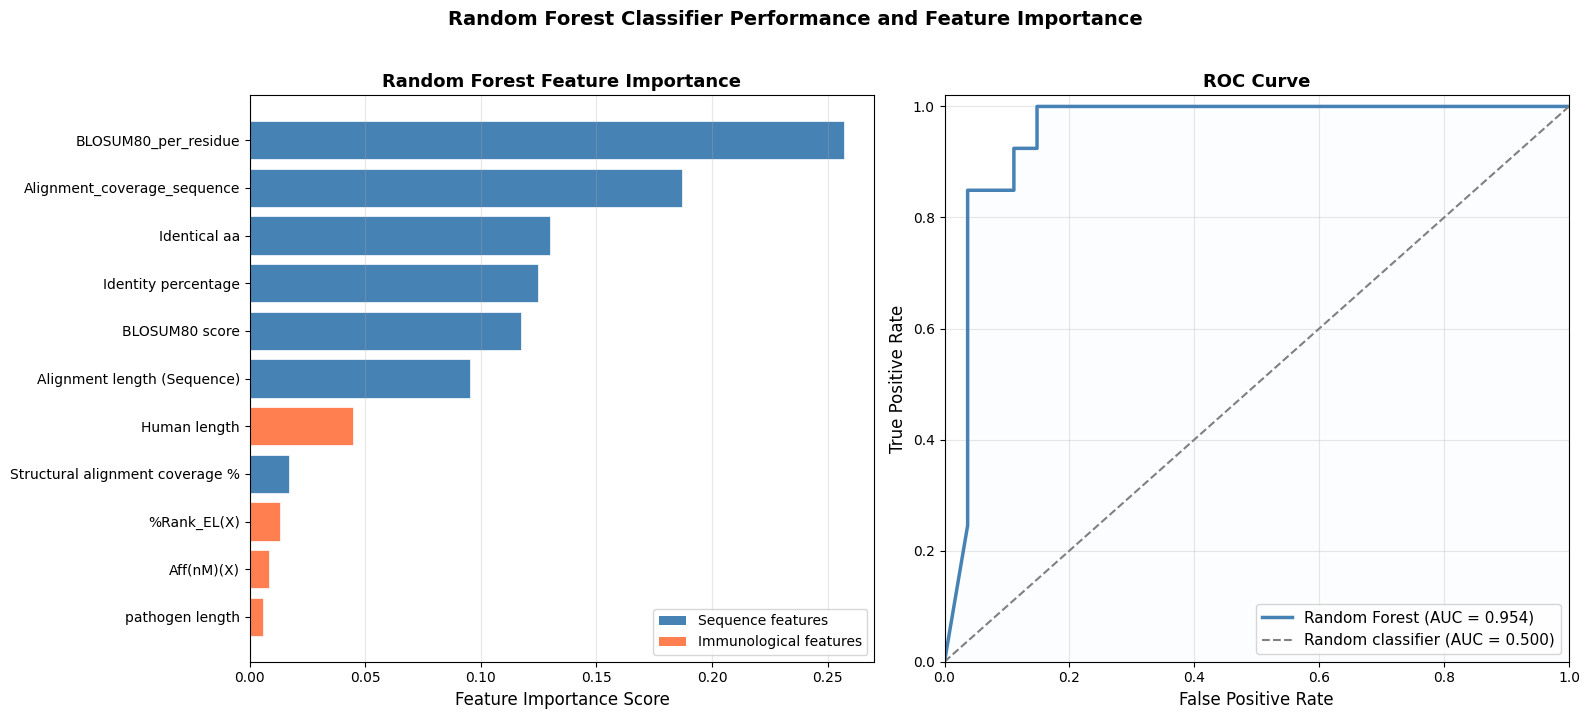

Feature importances ranked:
                        Feature  Importance
           BLOSUM80_per_residue    0.257316
    Alignment_coverage_sequence    0.186886
                   Identical aa    0.129895
            Identity percentage    0.124528
                 BLOSUM80 score    0.117185
    Alignment length (Sequence)    0.095388
                   Human length    0.044663
Structural alignment coverage %    0.016846
                    %Rank_EL(X)    0.013254
                     Aff(nM)(X)    0.008248
                pathogen length    0.005790


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_cols_ml,
    'Importance': importances
}).sort_values('Importance', ascending=True)

colors = []
sequence_features = [
    'BLOSUM80 score', 'Identity percentage',
    'Alignment length (Sequence)', 'Identical aa',
    'BLOSUM80_per_residue', 'Alignment_coverage_sequence',
    'Structural alignment coverage %'
]
for feat in importance_df['Feature']:
  if feat in sequence_features:
    colors.append('steelblue')
  else:
    colors.append('coral')

axes[0].barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color=colors,
    edgecolor='white',
    linewidth=0.5
)
axes[0].set_xlabel('Feature Importance Score', fontsize=12)
axes[0].set_title('Random Forest Feature Importance', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='Sequence features'),
    Patch(facecolor='coral', label='Immunological features')
]
axes[0].legend(handles=legend_elements, fontsize=10)


fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

axes[1].plot(
    fpr, tpr,
    color='steelblue',
    linewidth=2.5,
    label=f'Random Forest (AUC = {auc:.3f})'
)

axes[1].plot(
    [0, 1], [0, 1],
    color='gray',
    linestyle='--',
    linewidth=1.5,
    label='Random classifier (AUC = 0.500)'
)

axes[1].fill_between(fpr,tpr,alpha=0.01, color='steelblue')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.suptitle(
    'Random Forest Classifier Performance and Feature Importance',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('figure5_importance_roc.png', dpi=300, bbox_inches='tight')
plt.show()
print('Feature importances ranked:')
print(importance_df.sort_values('Importance', ascending=False).to_string(index=False))


In [25]:
# ── ADDITION: 5-fold stratified cross-validation ────────────────────────────
# A single 80-sample test set has high variance in performance estimates.
# Cross-validation gives mean ± SD.

from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

cv_results = cross_validate(
    rf_cv, X_filled, y_encoded,
    cv=cv,
    scoring=['roc_auc', 'recall', 'precision', 'accuracy'],
    return_train_score=False
)

print("=== 5-Fold Stratified Cross-Validation Results ===")
print(f"AUC-ROC:   {cv_results['test_roc_auc'].mean():.3f} ± {cv_results['test_roc_auc'].std():.3f}")
print(f"Recall:    {cv_results['test_recall'].mean():.3f} ± {cv_results['test_recall'].std():.3f}")
print(f"Precision: {cv_results['test_precision'].mean():.3f} ± {cv_results['test_precision'].std():.3f}")
print(f"Accuracy:  {cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}")
print()
print("Per-fold AUC scores:")
for i, score in enumerate(cv_results['test_roc_auc'], 1):
    print(f"  Fold {i}: {score:.3f}")
print()
print("Compare to held-out test set AUC:", round(auc, 3))
print()
if cv_results['test_roc_auc'].std() < 0.05:
    print("Low standard deviation across folds → performance is stable, not a lucky split.")
else:
    print("Note: moderate variance across folds — single split result should be interpreted cautiously.")

=== 5-Fold Stratified Cross-Validation Results ===
AUC-ROC:   0.987 ± 0.012
Recall:    0.988 ± 0.015
Precision: 0.963 ± 0.016
Accuracy:  0.967 ± 0.013

Per-fold AUC scores:
  Fold 1: 0.998
  Fold 2: 0.979
  Fold 3: 0.992
  Fold 4: 0.966
  Fold 5: 0.997

Compare to held-out test set AUC: 0.954

Low standard deviation across folds → performance is stable, not a lucky split.


The top six features by importance are ALL sequence features — blue bars. Every single immunological feature — %Rank_EL, Aff(nM), pathogen length, Human length — ranks at the bottom with importance scores below 0.05.

This means the model is succeeding almost entirely on sequence-derived features, not immunological ones.

* The Mann-Whitney tests showed sequence features cannot significantly separate the classes when examined individually. Yet the random forest achieves AUC 0.954 using those same features. This is not a contradiction — it is a well-known phenomenon in machine learning called feature interaction.

* Individual features have weak discriminative power alone, but in combination they become highly predictive. The random forest is learning decision boundaries that involve multiple features simultaneously — something a simple statistical test cannot detect.

* This shows that sequence features are individually insufficient but collectively powerful when combined in a multivariate classifier.

**The ROC curve:**

The curve hugs the top left corner tightly and barely touches the diagonal at all. AUC 0.954 is visually confirmed — the shaded area under the curve is nearly the entire square.


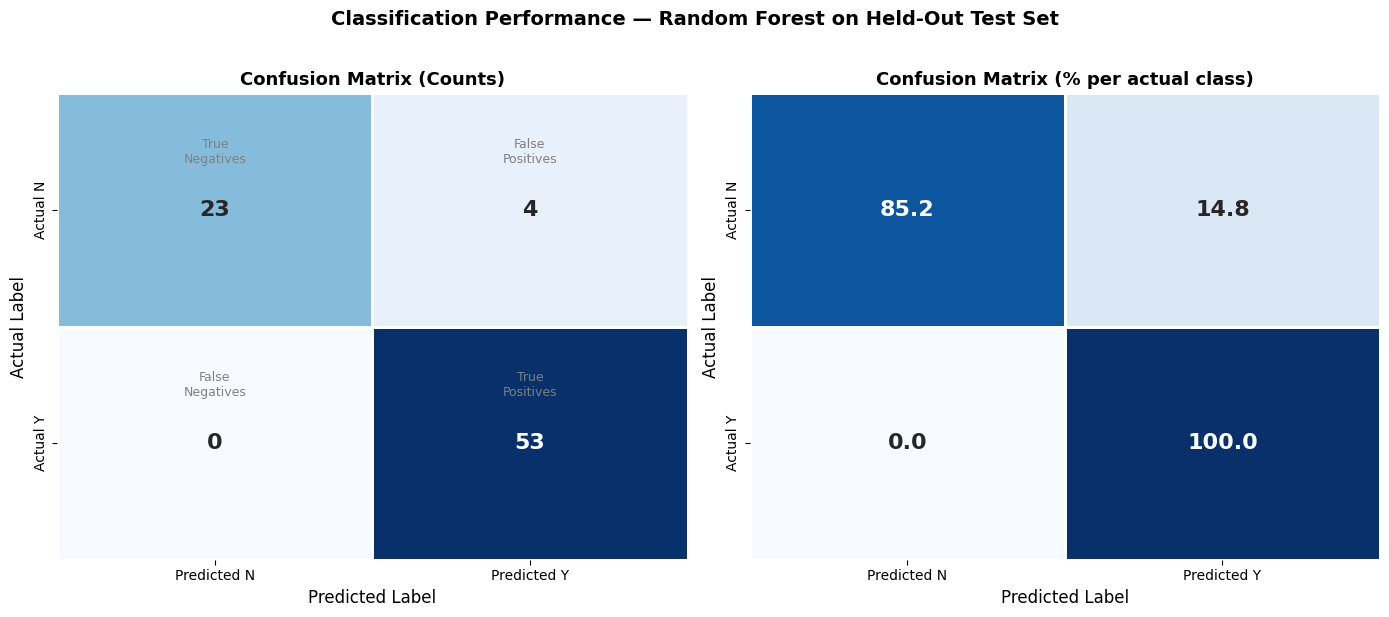

Test set performance summary:
True Negatives:  23 — Non-mimics correctly identified
False Positives: 4 — Non-mimics incorrectly called mimic
False Negatives: 0 — Mimics incorrectly called non-mimic
True Positives:  53 — Mimics correctly identified

Sensitivity (Recall for Y): 100.0%
Specificity (Recall for N): 85.2%


In [26]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted N', 'Predicted Y'],
    yticklabels=['Actual N', 'Actual Y'],
    linewidths=2,
    linecolor='white',
    ax=axes[0],
    cbar=False,
    annot_kws={'size': 16, 'weight': 'bold'}
)
axes[0].set_title('Confusion Matrix (Counts)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

axes[0].text(0.5, 0.25, 'True\nNegatives', transform=axes[0].transData,
             ha='center', va='center', fontsize=9, color='gray')
axes[0].text(1.5, 0.25, 'False\nPositives', transform=axes[0].transData,
             ha='center', va='center', fontsize=9, color='gray')
axes[0].text(0.5, 1.25, 'False\nNegatives', transform=axes[0].transData,
             ha='center', va='center', fontsize=9, color='gray')
axes[0].text(1.5, 1.25, 'True\nPositives', transform=axes[0].transData,
             ha='center', va='center', fontsize=9, color='gray')

cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    xticklabels=['Predicted N', 'Predicted Y'],
    yticklabels=['Actual N', 'Actual Y'],
    linewidths=2,
    linecolor='white',
    ax=axes[1],
    cbar=False,
    annot_kws={'size': 16, 'weight': 'bold'}
)
axes[1].set_title('Confusion Matrix (% per actual class)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.suptitle(
    'Classification Performance — Random Forest on Held-Out Test Set',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('figure6_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Test set performance summary:")
print(f"True Negatives:  {cm[0,0]} — Non-mimics correctly identified")
print(f"False Positives: {cm[0,1]} — Non-mimics incorrectly called mimic")
print(f"False Negatives: {cm[1,0]} — Mimics incorrectly called non-mimic")
print(f"True Positives:  {cm[1,1]} — Mimics correctly identified")
print(f"\nSensitivity (Recall for Y): {cm[1,1]/(cm[1,0]+cm[1,1])*100:.1f}%")
print(f"Specificity (Recall for N): {cm[0,0]/(cm[0,0]+cm[0,1])*100:.1f}%")

**Left panel — raw counts:**

23 true negatives, 4 false positives, 0 false negatives, 53 true positives. The zero in the false negatives cell is the strongest result — the model never missed a confirmed mimic.

**Right panel — percentages:**

100% sensitivity — every single mimic was found. 85.2% specificity — 14.8% of non-mimics were incorrectly flagged as mimics.